# level 3

# Task-1 Predictive modeling

In [1]:
import pandas as pd

df = pd.read_csv("Dataset .csv")

print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [ ]:
# main libraries for model comparison
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import pandas as pd

In [ ]:
# Convert 'Yes'/'No' to 1/0 for 'Has Table booking' and 'Has Online delivery'
df['Has Table Booking'] = df['Has Table booking'].map({
    'Yes': 1,
    'No': 0
})

df['Has Online Delivery'] = df['Has Online delivery'].map({
    'Yes': 1,
    'No': 0
})

In [ ]:
# Define features and target variable
features = [
    'Price range',
    'Votes',
    'Average Cost for two',
    'Has Table Booking',
    'Has Online Delivery'
]

X = df[features]
y = df['Aggregate rating']

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (7640, 5)
Testing Data: (1911, 5)


In [7]:
# Train models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_predictions))
print("Linear Regression R²:", r2_score(y_test, lr_predictions))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_predictions))
print("Random Forest R²:", r2_score(y_test, rf_predictions))
import joblib
joblib.dump(lr_model, 'linear_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')
print("Models saved successfully.")

Linear Regression MAE: 1.075071272136913
Linear Regression R²: 0.26344464090219477
Random Forest MAE: 0.2365405468876994
Random Forest R²: 0.9410704744688583
Models saved successfully.


In [8]:
# compare models
print("Comparing Models:")
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_predictions))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_predictions))
print("Linear Regression R²:", r2_score(y_test, lr_predictions))
print("Random Forest R²:", r2_score(y_test, rf_predictions))


Comparing Models:
Linear Regression MAE: 1.075071272136913
Random Forest MAE: 0.2365405468876994
Linear Regression R²: 0.26344464090219477
Random Forest R²: 0.9410704744688583


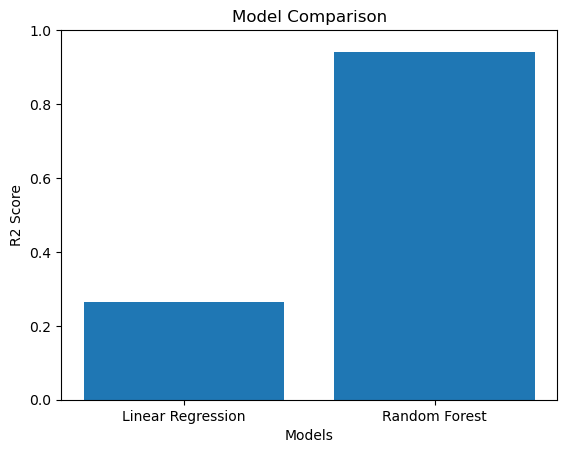

In [11]:
# Visualize model performance
models = ['Linear Regression', 'Random Forest']

scores = [
    r2_score(y_test, lr_predictions),
    r2_score(y_test, rf_predictions)
]

import matplotlib.pyplot as plt

plt.bar(models, scores)
plt.ylim(0, 1)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

# Task-2 Customer preference analysis

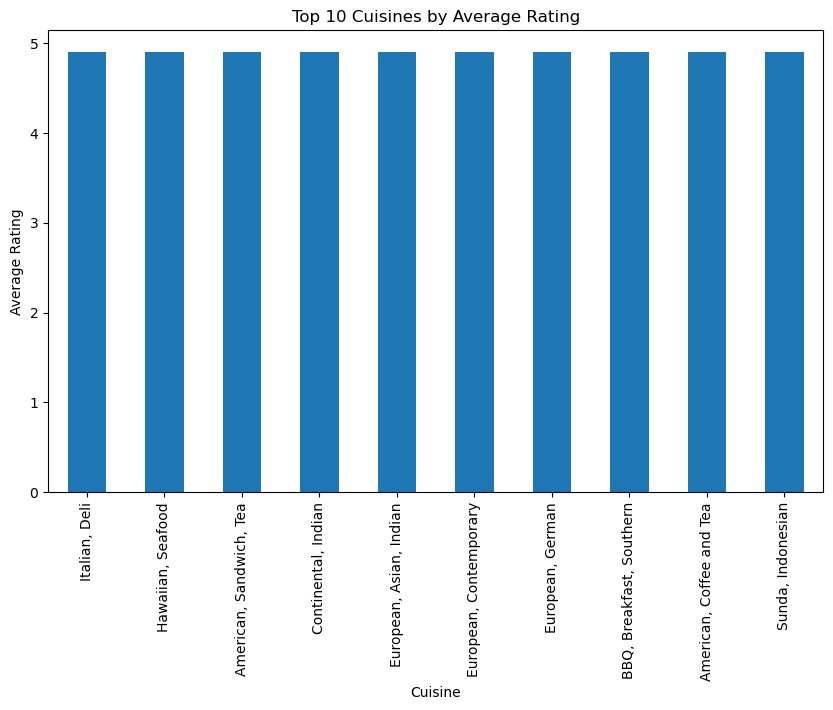

In [13]:
# cuisin and ratings
cuisine_ratings = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
top_cuisines = cuisine_ratings.head(10)
plt.figure(figsize=(10, 6))
top_cuisines.plot(kind='bar')
plt.title('Top 10 Cuisines by Average Rating')
plt.xlabel('Cuisine')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)
plt.show()


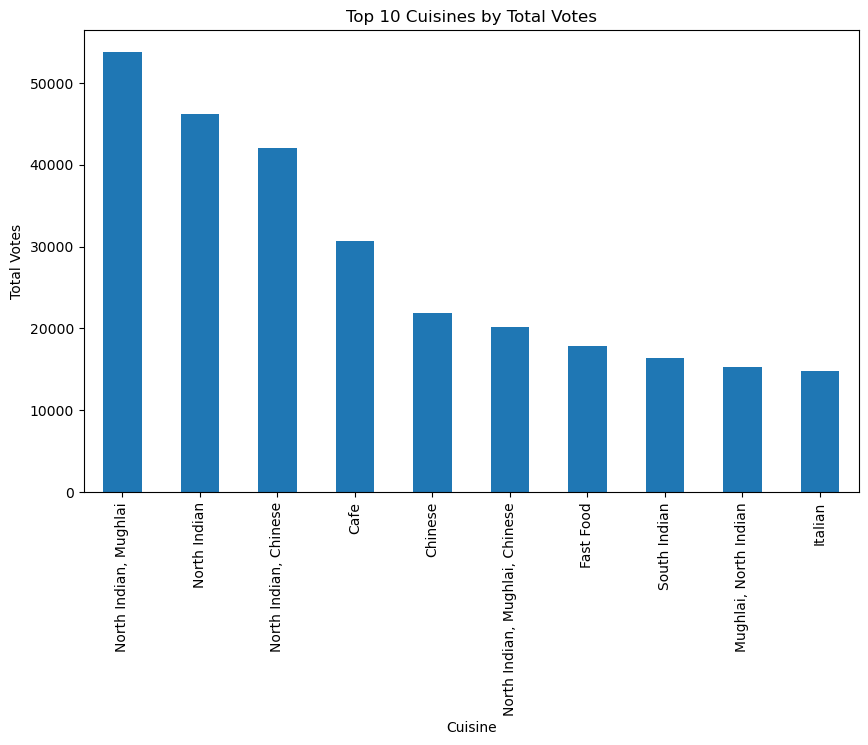

In [14]:
# most voted cuisines
cuisine_votes = df.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False)
top_voted_cuisines = cuisine_votes.head(10)
plt.figure(figsize=(10, 6))
top_voted_cuisines.plot(kind='bar')
plt.title('Top 10 Cuisines by Total Votes')
plt.xlabel('Cuisine')
plt.ylabel('Total Votes')
plt.xticks(rotation=90)
plt.show()

In [18]:
# identify cusines with high ratings but low votes
cuisine_summary = pd.DataFrame({
    'Average Rating': df.groupby('Cuisines')['Aggregate rating'].mean(),
    'Total Votes': df.groupby('Cuisines')['Votes'].sum()
})
high_rated_low_votes = cuisine_summary[(cuisine_summary['Average Rating'] > 4) & (cuisine_summary['Total Votes'] < cuisine_summary['Total Votes'].quantile(0.25))]
print("Cuisines with High Ratings but Low Votes:")
print(high_rated_low_votes)


Cuisines with High Ratings but Low Votes:
                                                    Average Rating  \
Cuisines                                                             
Asian, Chinese, Tibetan                                        4.1   
BBQ, Grill, Brazilian                                          4.3   
Bakery, Sandwich, Brazilian                                    4.4   
Beverages, Bar Food, Fast Food                                 4.5   
Beverages, Salad, Beverages                                    4.3   
Brazilian, Healthy Food, Juices, Pizza                         4.6   
Brazilian, Italian                                             4.3   
Brazilian, North Eastern                                       4.4   
Brazilian, Seafood                                             4.2   
Breakfast, Modern Australian                                   4.1   
Cafe, Coffee and Tea, Western                                  4.2   
Cafe, Italian, Continental, Mexican             

In [20]:
# corelation between votes and ratings
correlation = df['Votes'].corr(df['Aggregate rating'])
print("Correlation between Votes and Aggregate Rating:", correlation)
print("Correlation Interpretation:")
if correlation > 0.5:
    print("Strong positive correlation: Higher votes are associated with higher ratings.")
elif correlation > 0:
    print("Weak positive correlation: Higher votes are somewhat associated with higher ratings.")
elif correlation < -0.5:
    print("Strong negative correlation: Higher votes are associated with lower ratings.")
elif correlation < 0:
    print("Weak negative correlation: Higher votes are somewhat associated with lower ratings.")
else:
    print("No correlation: Votes and ratings are not related.")
    

Correlation between Votes and Aggregate Rating: 0.31369058419541135
Correlation Interpretation:
Weak positive correlation: Higher votes are somewhat associated with higher ratings.


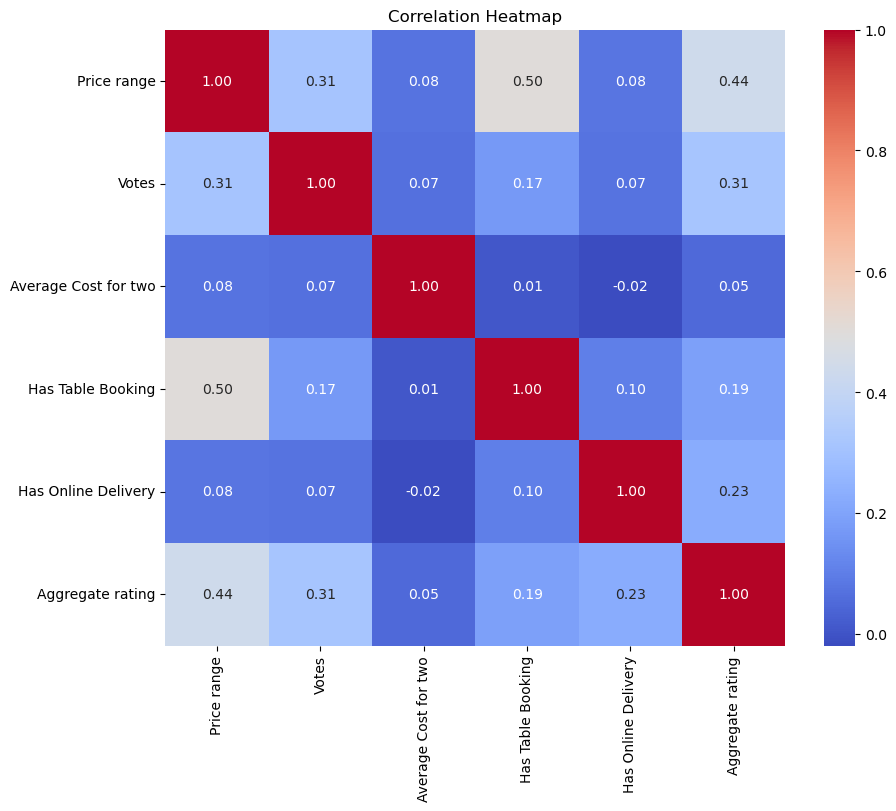

In [21]:
# heatmap of correlation between features and target variable
import seaborn as sns
correlation_matrix = df[features + ['Aggregate rating']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


# Task-3 Data Visualization

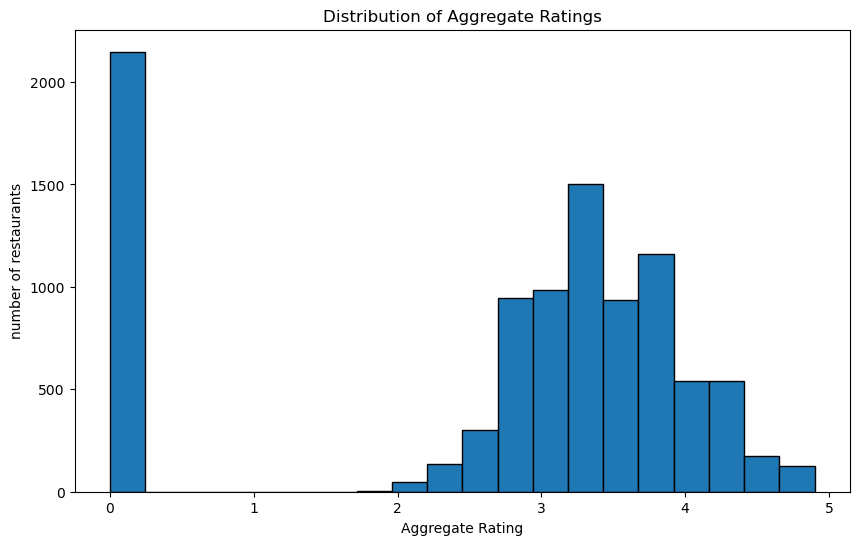

In [25]:
# rating distribution histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Aggregate rating'], bins=20, edgecolor='black')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('number of restaurants')
plt.show()

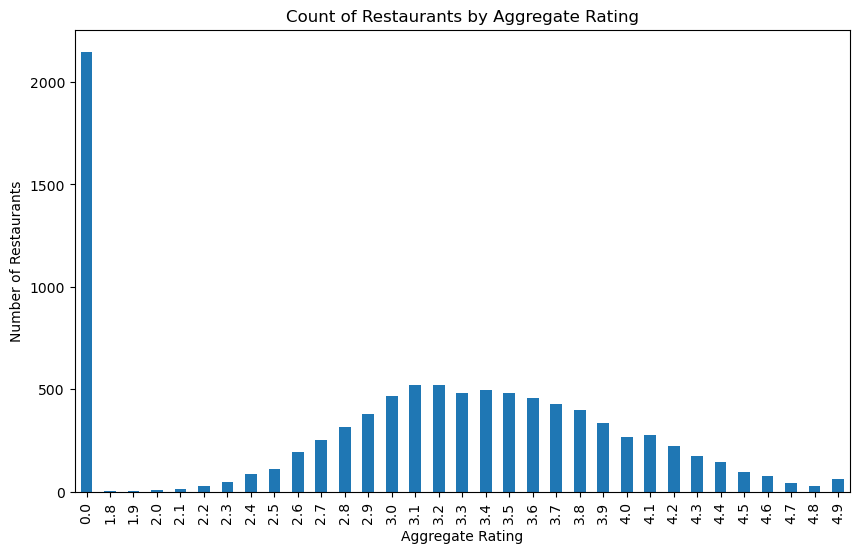

In [26]:
# rating count bar chart
rating_counts = df['Aggregate rating'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
rating_counts.plot(kind='bar')
plt.title('Count of Restaurants by Aggregate Rating')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.show()


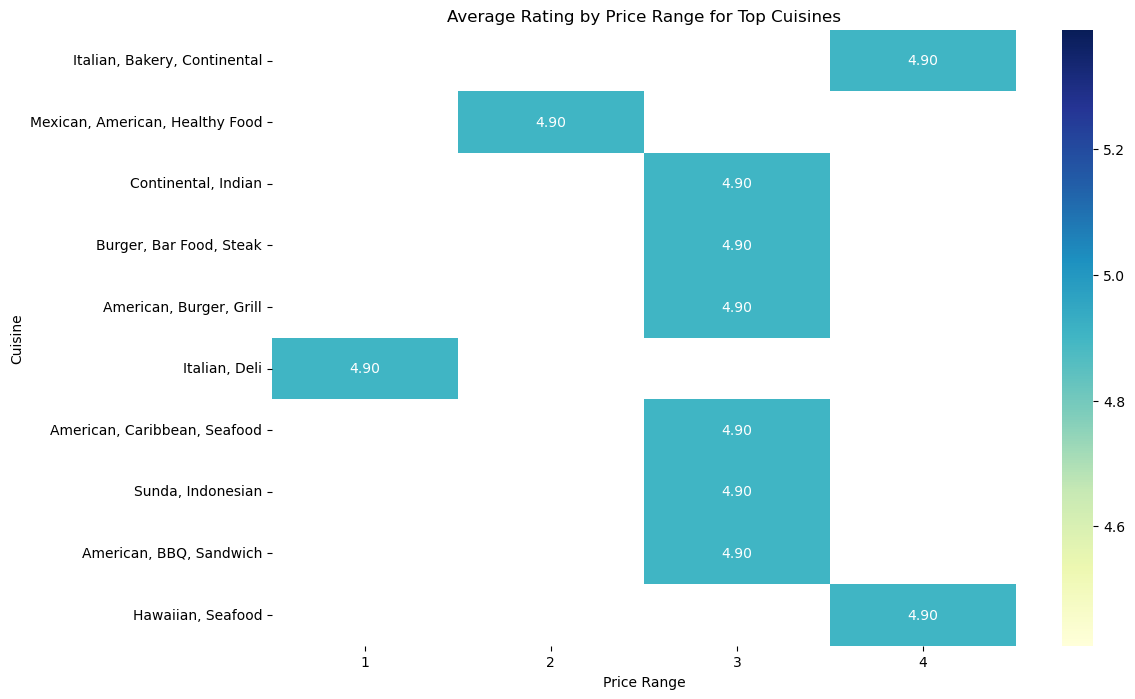

In [27]:
# average rating by price range of top cuisines
cuisine_price_rating = df.groupby(['Cuisines', 'Price range'])['Aggregate rating'].mean().unstack()
top_cuisines = cuisine_price_rating.mean(axis=1).sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 8))
sns.heatmap(cuisine_price_rating.loc[top_cuisines.index], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Average Rating by Price Range for Top Cuisines')
plt.xlabel('Price Range')
plt.ylabel('Cuisine')
plt.show()


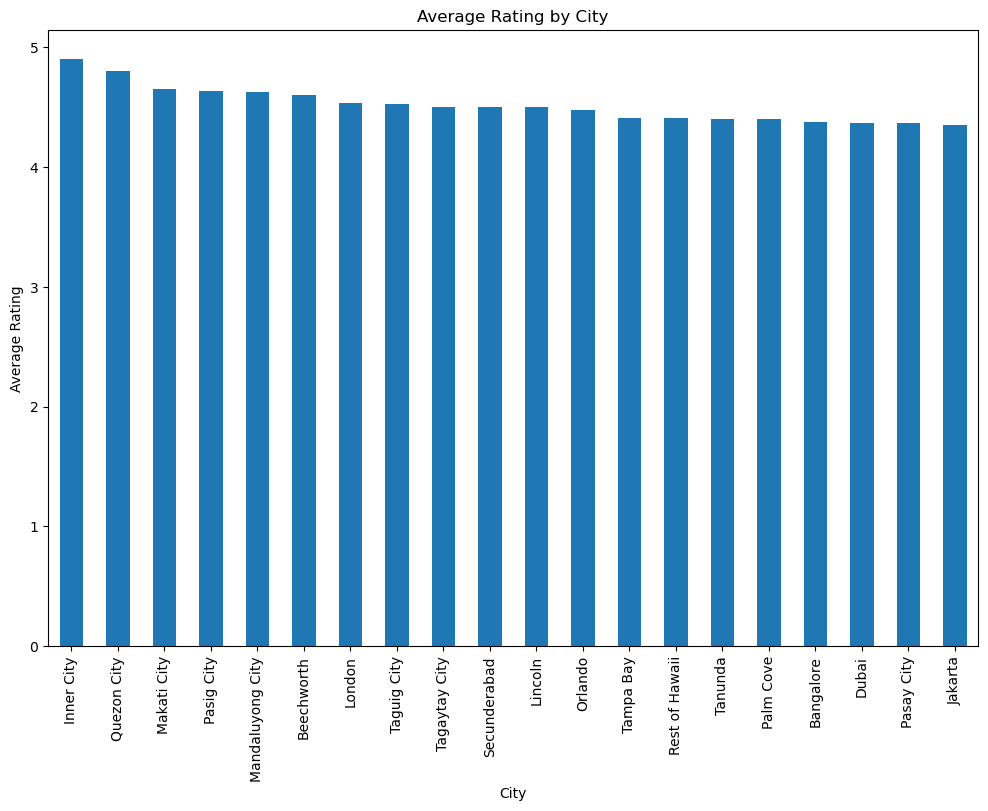

In [29]:
# Average rating by city
city_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 8))
city_rating.plot(kind='bar')
plt.title('Average Rating by City')
plt.xlabel('City')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)
plt.show()

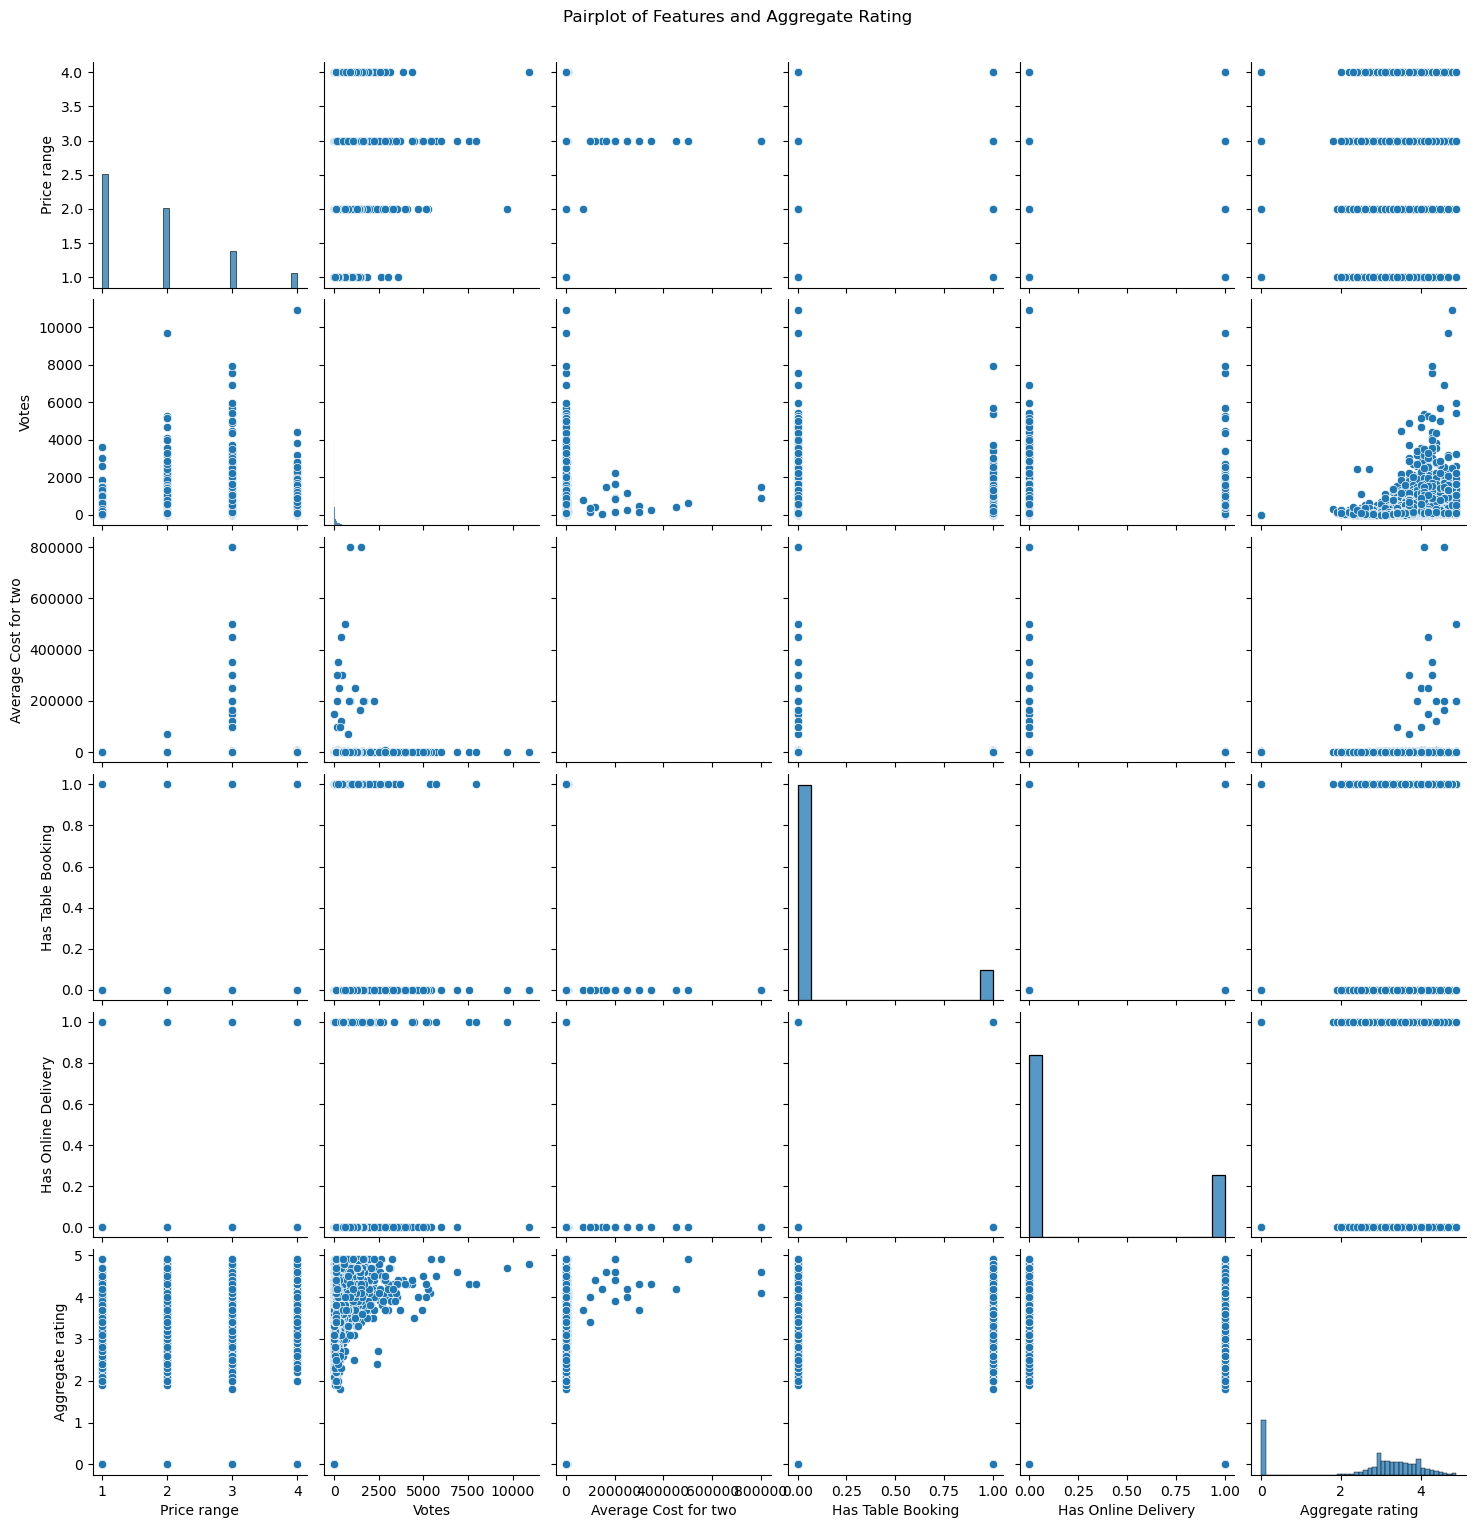

In [30]:
# relationship between features and ratings
import seaborn as sns
sns.pairplot(df[features + ['Aggregate rating']])
plt.suptitle('Pairplot of Features and Aggregate Rating', y=1.02)
plt.show()

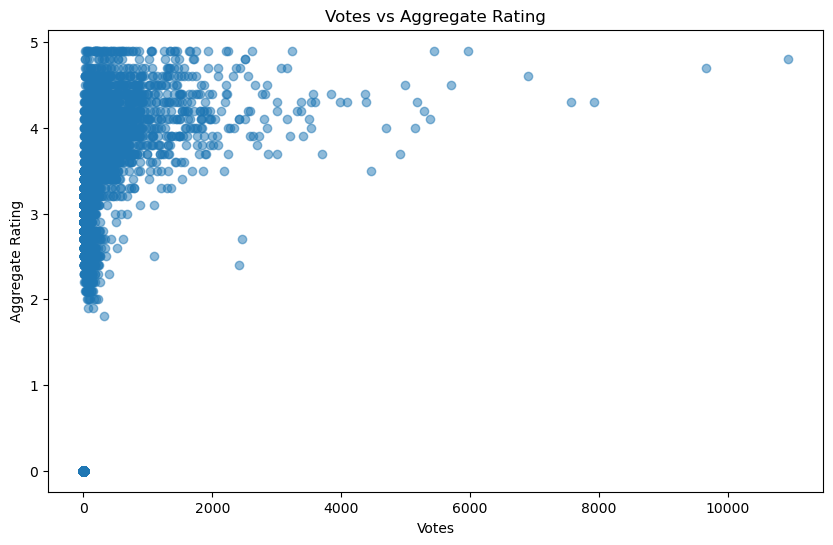

In [31]:
# scatter plot of votes vs ratings
plt.figure(figsize=(10, 6))
plt.scatter(df['Votes'], df['Aggregate rating'], alpha=0.5)
plt.title('Votes vs Aggregate Rating')
plt.xlabel('Votes')
plt.ylabel('Aggregate Rating')
plt.show()